# Getting started with MOFA-FLEX

MOFA-FLEX is a framework for factor analysis of multimodal data, with a focus on single-cell omics, representing an observed data matrix $\mat{Y}$ as a product of a low-rank factor matrix $\mat{Z}$ and a low-rank weight matrix $\mat{W}$: $\mat{Y} \approx \mat{Z} \mat{W}$.
It is essentially a synthesis of MOFA{cite:p}`pmid29925568,pmid32393329`, MEFISTO{cite:p}`pmid35027765`, MuVI{cite:p}`pmlr-v206-qoku23a`, nonnegative matrix factorization, and NSF{cite:p}`pmid36587187`.
It natively supports [MuData](https://mudata.readthedocs.io) and [AnnData](https://anndata.readthedocs.io) objects, integrating into the wider [scverse](https://scverse.org) ecosystem.

For this notebook, we will use the [pbmc3k dataset by 10x Genomics](https://www.10xgenomics.com/resources/datasets/pbmc-from-a-healthy-donor-granulocytes-removed-through-cell-sorting-3-k-1-standard-2-0-0), conveniently packaged in the `mudatasets` package.
The dataset contains 10 000 single cells profiled with the 10x multiome assay, capturing gene expression (scRNAseq) and chromatin accessibility (scATACseq).

In [1]:
import mudata as md
import mudatasets as mds
import muon as mu
import mofaflex as mfl
import scanpy as sc
from plotnine import *

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
theme_set(theme_bw())
md.set_options(display_style="html", display_html_expand=0);

In [3]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
mdata = mds.load("pbmc3k_multiome")

■ File filtered_feature_bc_matrix.h5 from pbmc3k_multiome has been found at /home/kats/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5
■ Checksum is validated (md5) for filtered_feature_bc_matrix.h5
■ Loading filtered_feature_bc_matrix.h5...


/data/ilia/envs/famo/lib/python3.11/site-packages/mudatasets/core.py:203: UserWarning: Dataset is in the 10X .h5 format and can't be loaded as backed.
/data/ilia/envs/famo/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/data/ilia/envs/famo/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Added `interval` annotation for features from /home/kats/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5


/data/ilia/envs/famo/lib/python3.11/site-packages/mudata/_core/mudata.py:938: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.


In [5]:
mdata.var_names_make_unique()
mdata

rna,bool,numpy.ndarray,
atac,bool,numpy.ndarray,


## Preprocessing

We first perform the basic preprocessing steps outlined in the [muon tutorial](inv:muon-tutorials#/single-cell-rna-atac/pbmc10k/1-gene-expression-processing.ipynb) to remove undetected genes and poor-quality cells.

In [6]:
rna = mdata["rna"]
rna.var["mt"] = rna.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    rna, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
mu.pp.filter_var(rna, "n_cells_by_counts", lambda x: x >= 3)
mu.pp.filter_obs(rna, "n_genes_by_counts", lambda x: (x >= 200) & (x < 5000))

mu.pp.filter_obs(rna, "total_counts", lambda x: x < 15000)
mu.pp.filter_obs(rna, "pct_counts_mt", lambda x: x < 20)

atac = mdata.mod["atac"]
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
mu.pp.filter_var(atac, "n_cells_by_counts", lambda x: x >= 10)
mu.pp.filter_obs(atac, "n_genes_by_counts", lambda x: (x >= 2000) & (x <= 15000))
mu.pp.filter_obs(atac, "total_counts", lambda x: (x >= 4000) & (x <= 40000))

We further normalize the data and subselect highly variable genes that will be used in the analysis.

In [7]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)

mu.atac.pp.tfidf(atac, scale_factor=1e4)
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=0.5)
mu.pp.filter_var(atac, atac.var_names[atac.var.highly_variable])

mdata.update()

In [8]:
mdata

MuData object with n_obs × n_vars = 2695 × 42241
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
  2 modalities
    rna:	2636 x 21256
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg'
    atac:	2450 x 20985
      obs:	'n_genes_by_counts', 'total_counts', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg'

## Fitting a model

Creating a [MOFAFLEX](#mofaflex.MOFAFLEX) object automatically fits the model using the specified parameters.
A basic understanding of the [model](#modeldescription) is required to correctly set the parameters for a given dataset.

The main deviation from the MOFA-FLEX defaults that we will make for the pbmc10k dataset is using a negative binomial likelihood, which is more appropriate for count data than the default Gaussian likelihood.
With default settings, MOFA-FLEX will plot the number of observations in each view and group.
This can be turned off by customizing [](#mofaflex.DataOptions).
MOFA-FLEX will also automatically save the final model after training which can later be loaded with [](#mofaflex.MOFAFLEX.load).
The name of the saved file can be changed in [](#mofaflex.TrainingOptions).

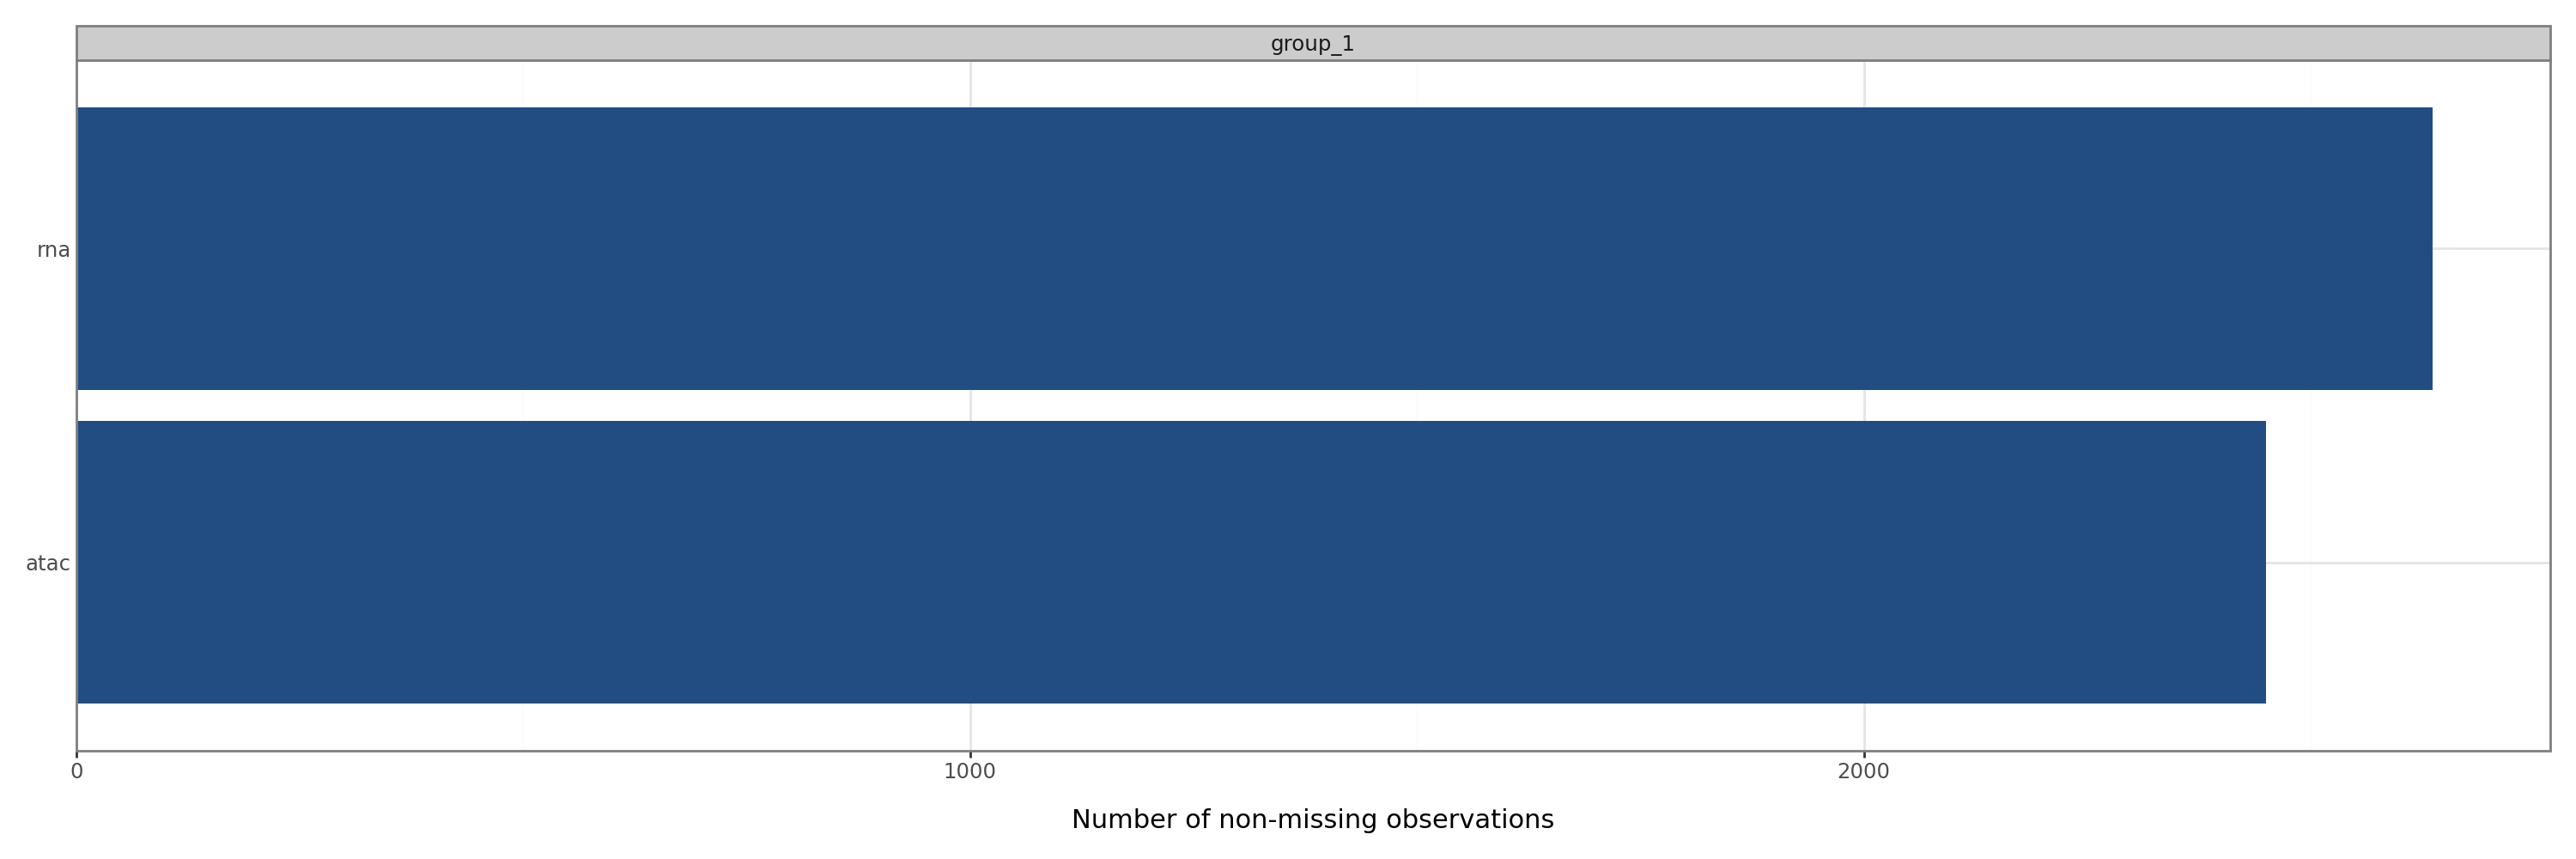

WARNING	Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.
INFO	Initializing factors using `random` method...


  0%|                                                                                                         …

INFO 	 Guessed max_plate_nesting = 3
INFO	Training converged after 1218 epochs.
INFO	Saving results to mofaflex_20250711_102005.h5...


In [9]:
model = mfl.MOFAFLEX(
    mdata,
    mfl.ModelOptions(n_factors=15, likelihoods="Normal"),
    mfl.TrainingOptions(batch_size=1000, seed=42),
)

We can plot the loss curve to get an overview of the training process:

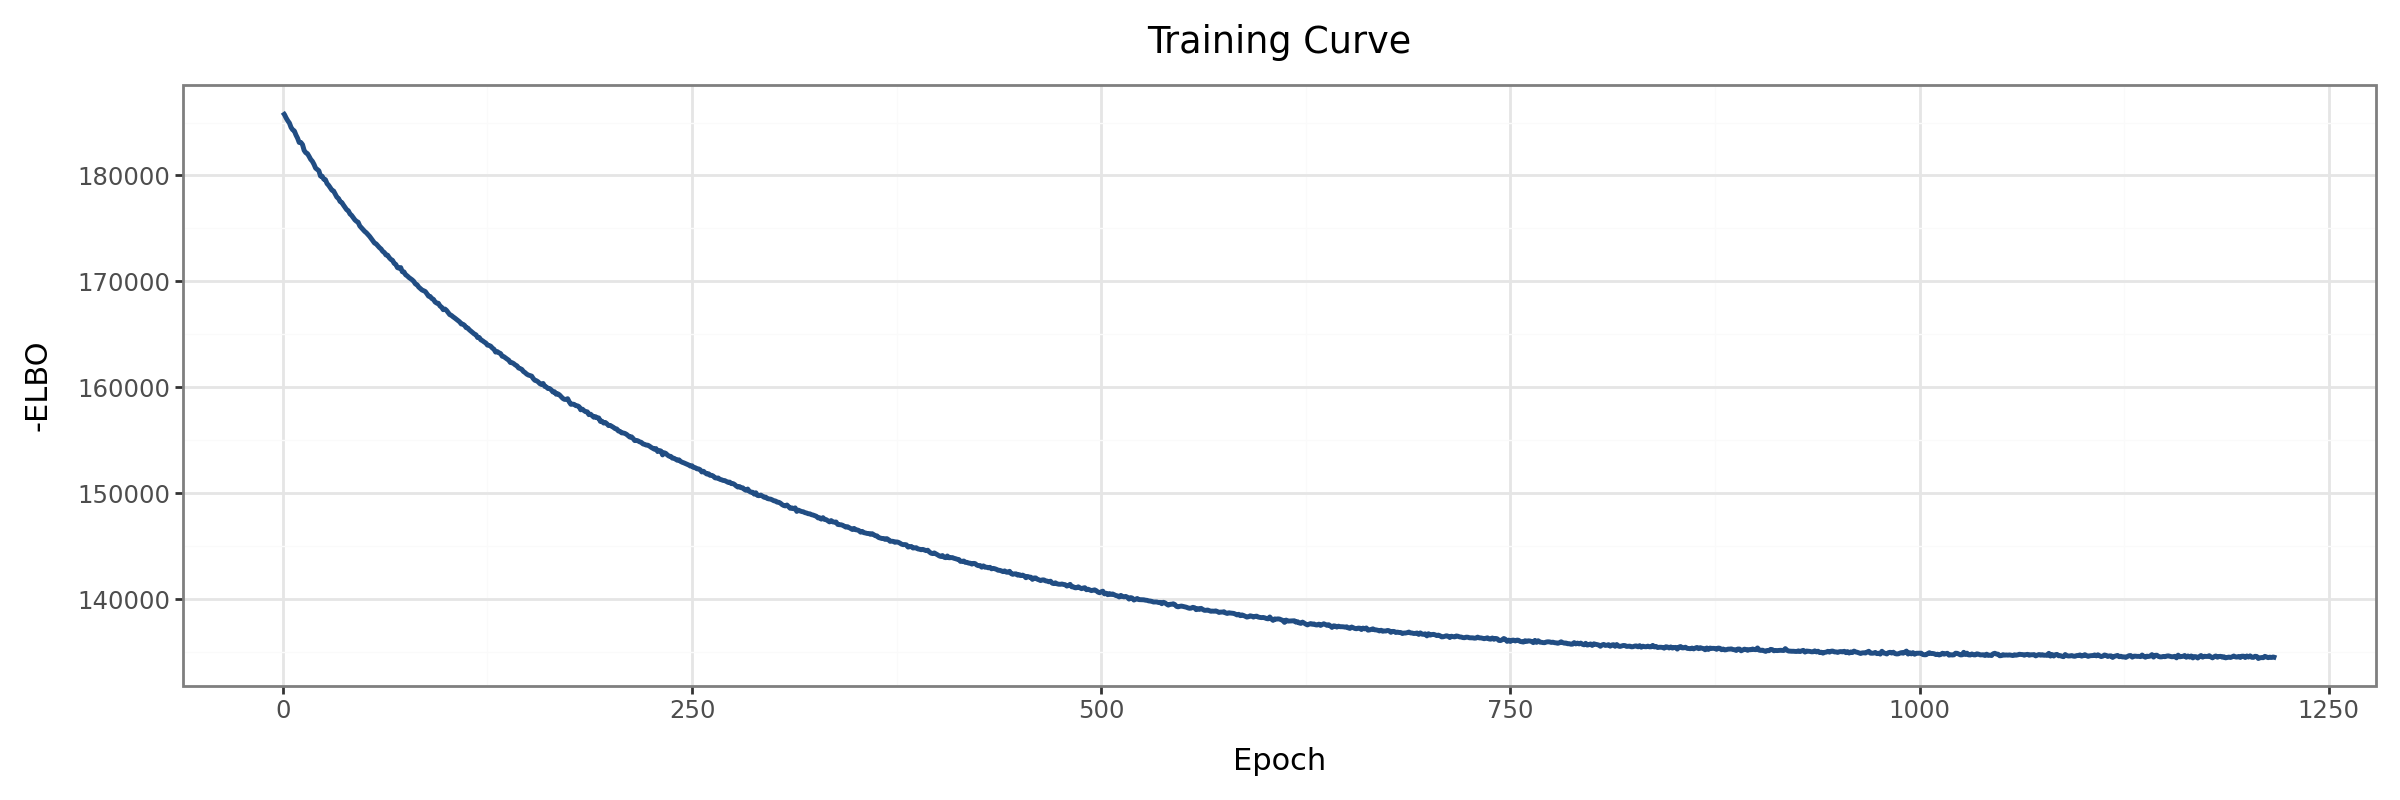

In [10]:
mfl.pl.training_curve(model)

## Analysing the model
The trained model can now be analysed to assess its quality and discover relevant biology.
First, we plot the correlations between factors, which should be as low as possible: We want factors to be uncorrelated, as each factor should capture a different aspect of the data.

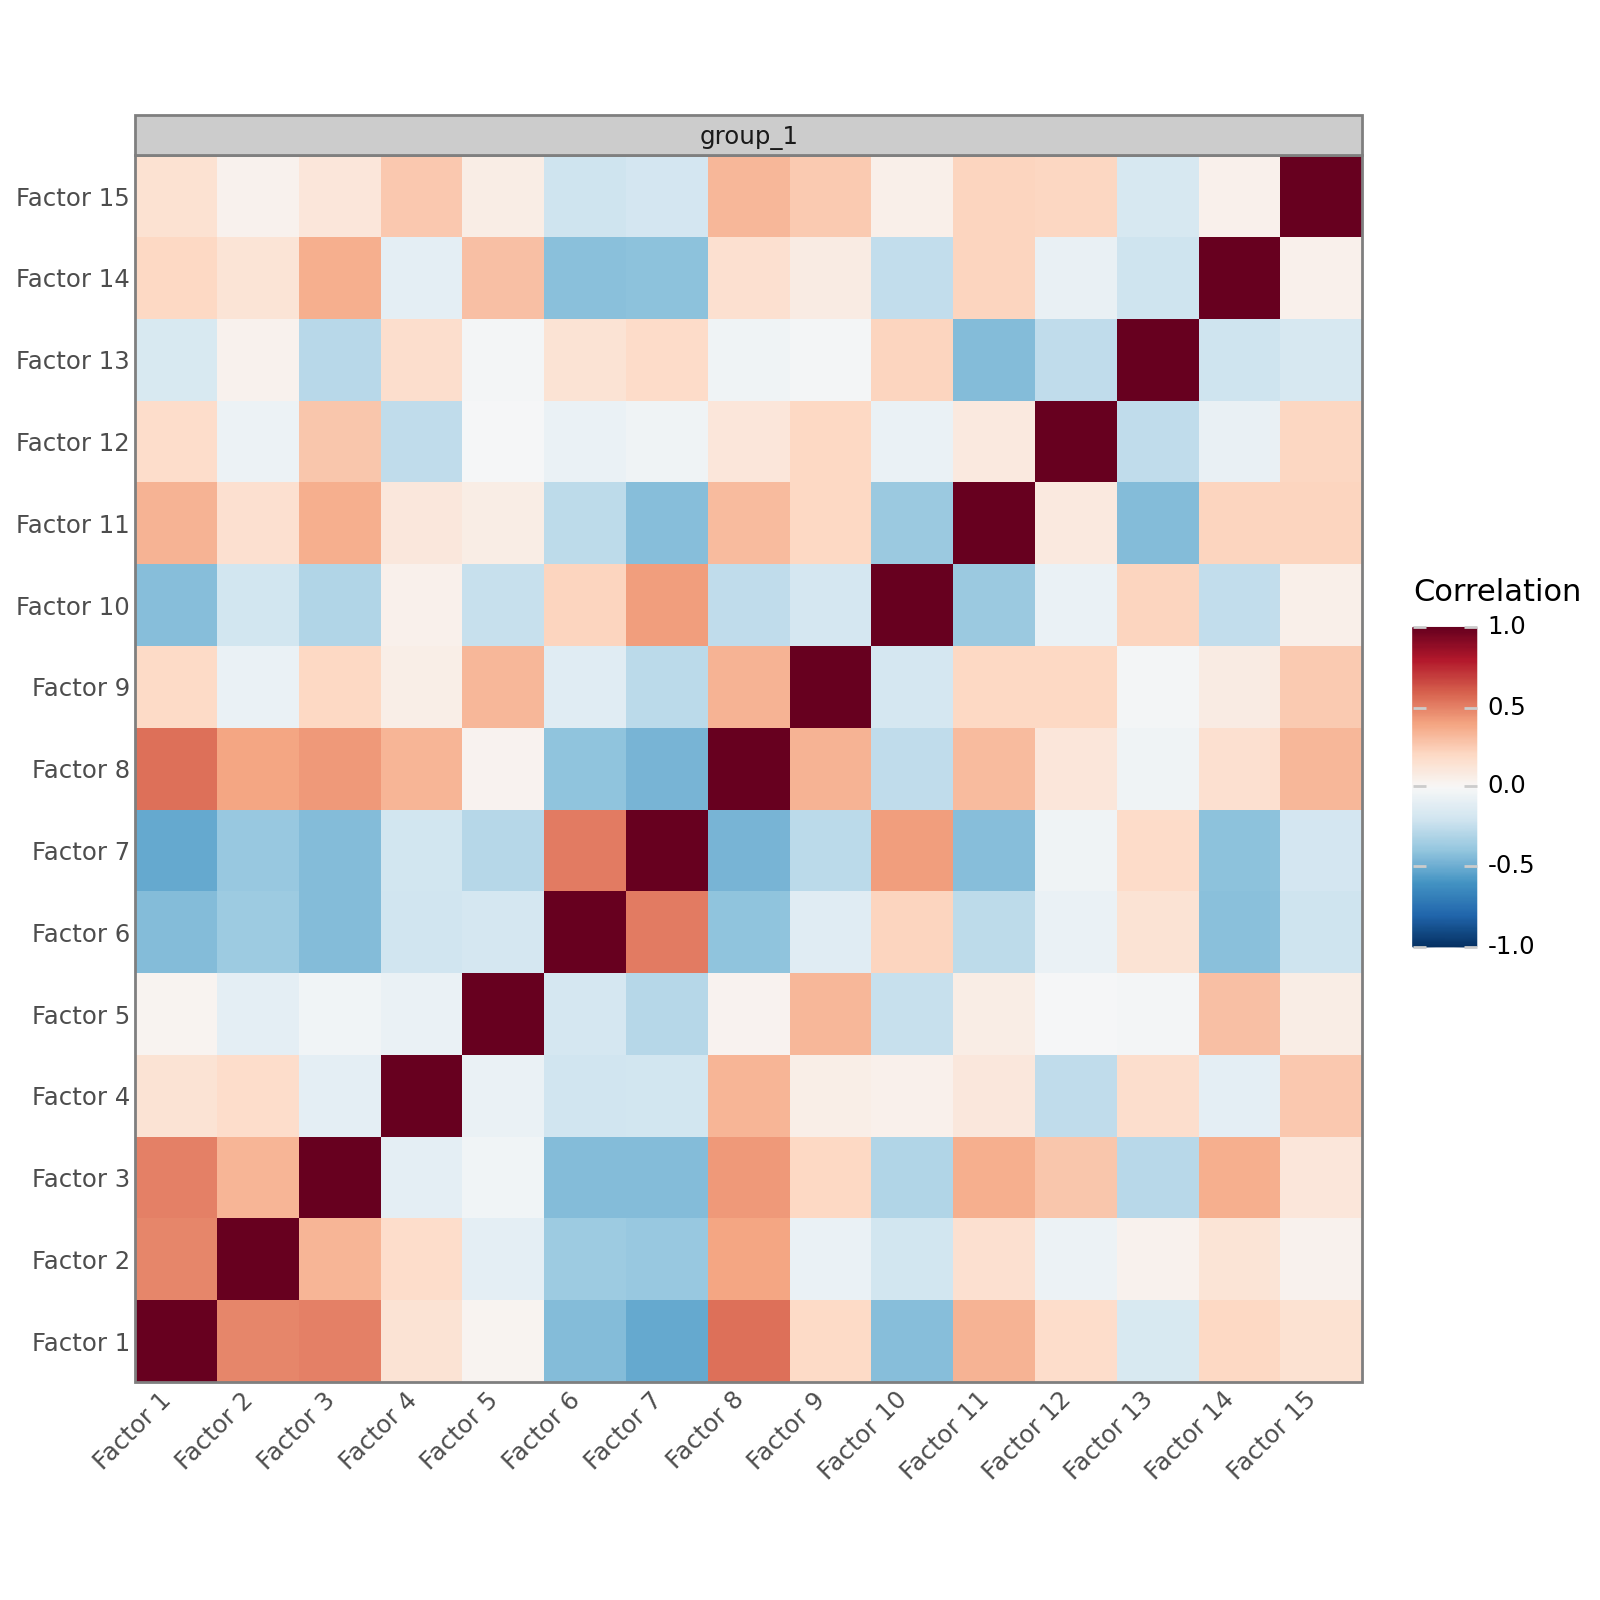

In [11]:
mfl.pl.factor_correlation(model)

This is not ideal, but good enough for a first look at the data.
We can now plot the fraction of variance in the data explained by each factor to determine the most important factors.
Note that for non-Normal likelihoods, these values are approximate.

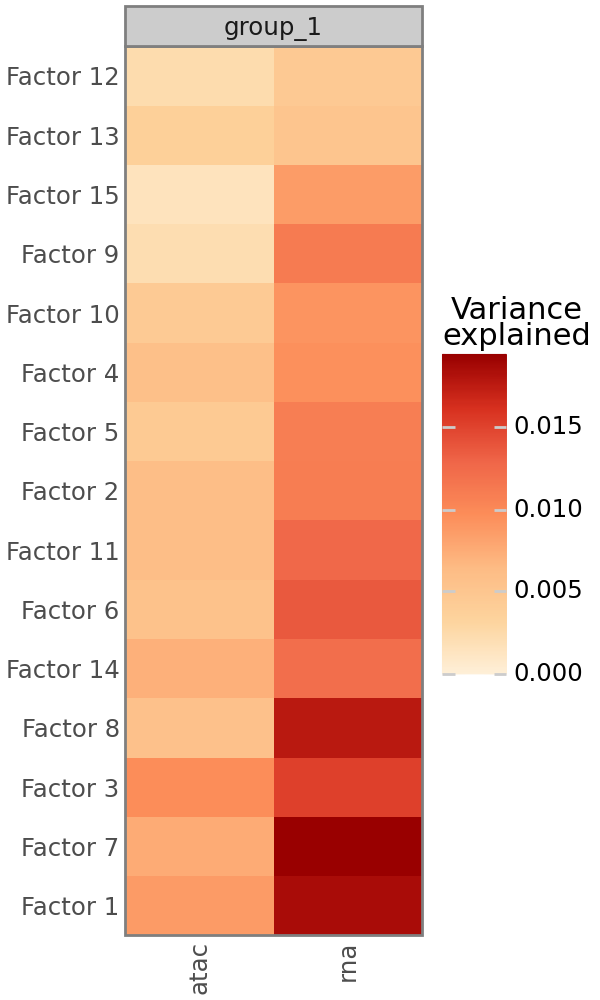

In [12]:
mfl.pl.variance_explained(model)

We can plot the most important genes per factor to get an idea of what each factor represents.
This plot aggregates over all views.

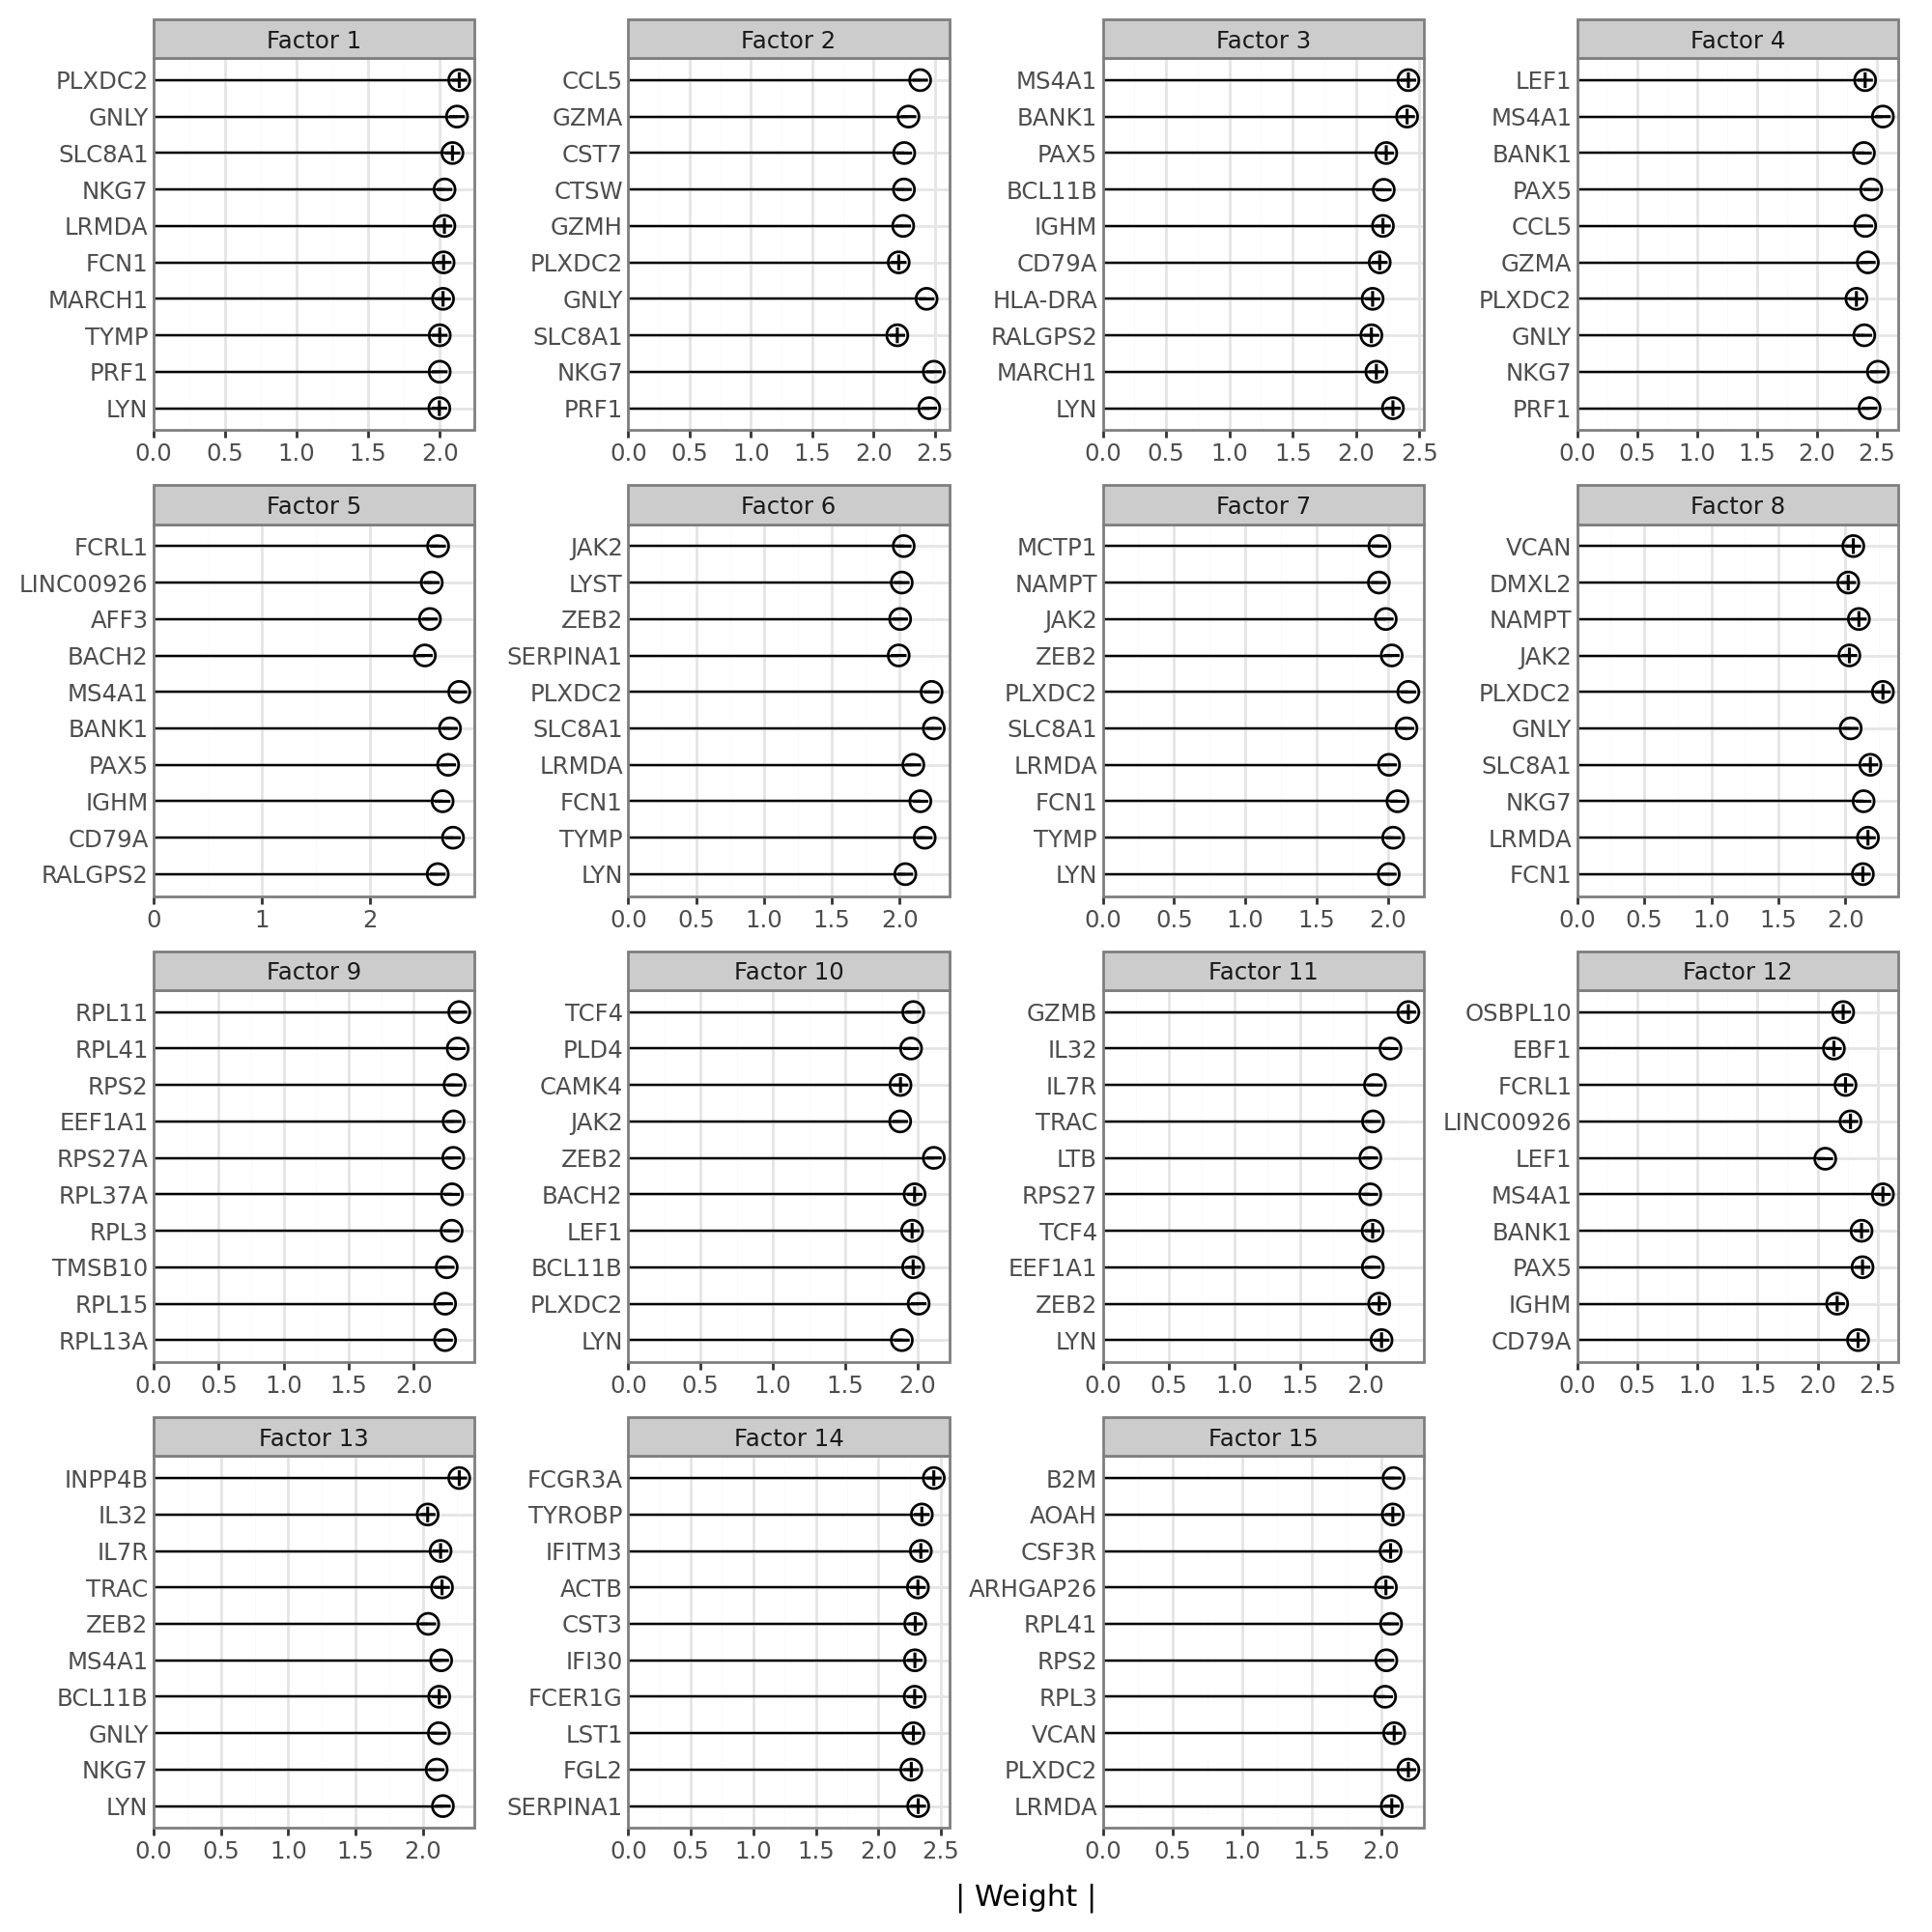

In [13]:
mfl.pl.top_weights(model, figsize=(10, 10))

It appears that the most important features are all from the RNA dataset.
We can use a different plotting function to get the top weights individually for each view.

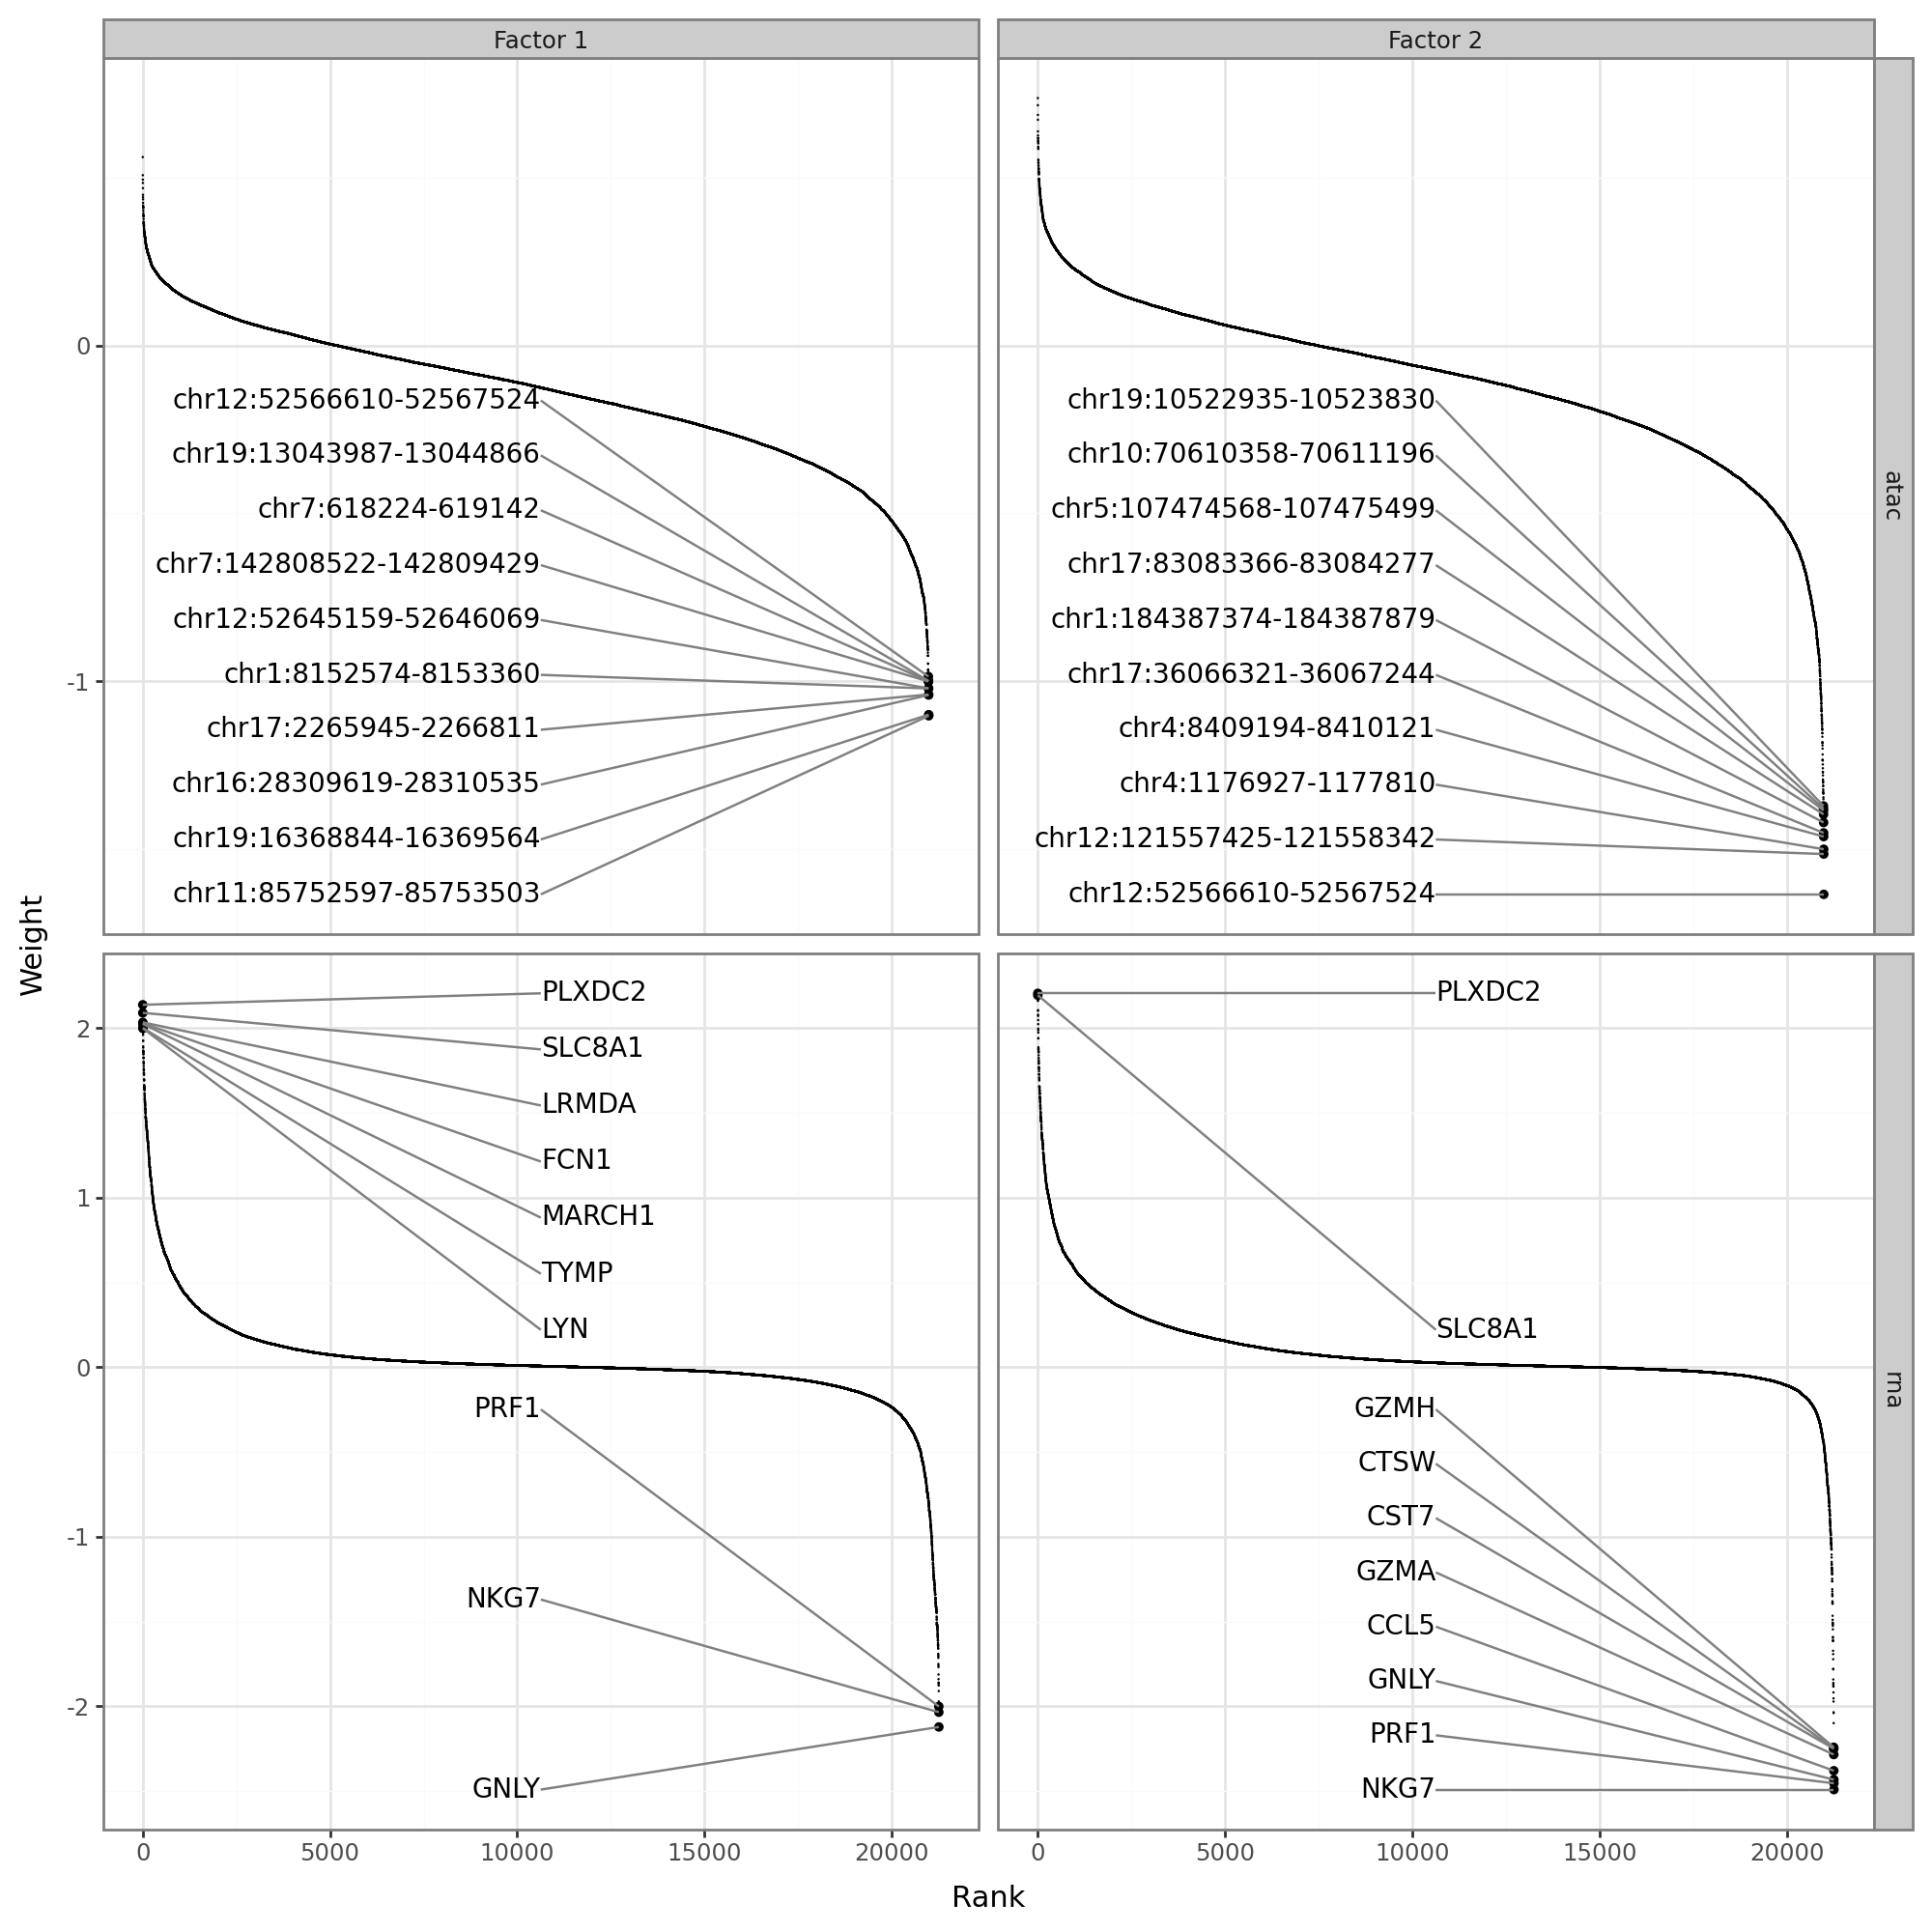

In [14]:
mfl.pl.weights(model, factors=(1, 2), figsize=(10, 10))

We can also plot factors agains each other.
This may be useful to define clusters of cells with similar factor values.

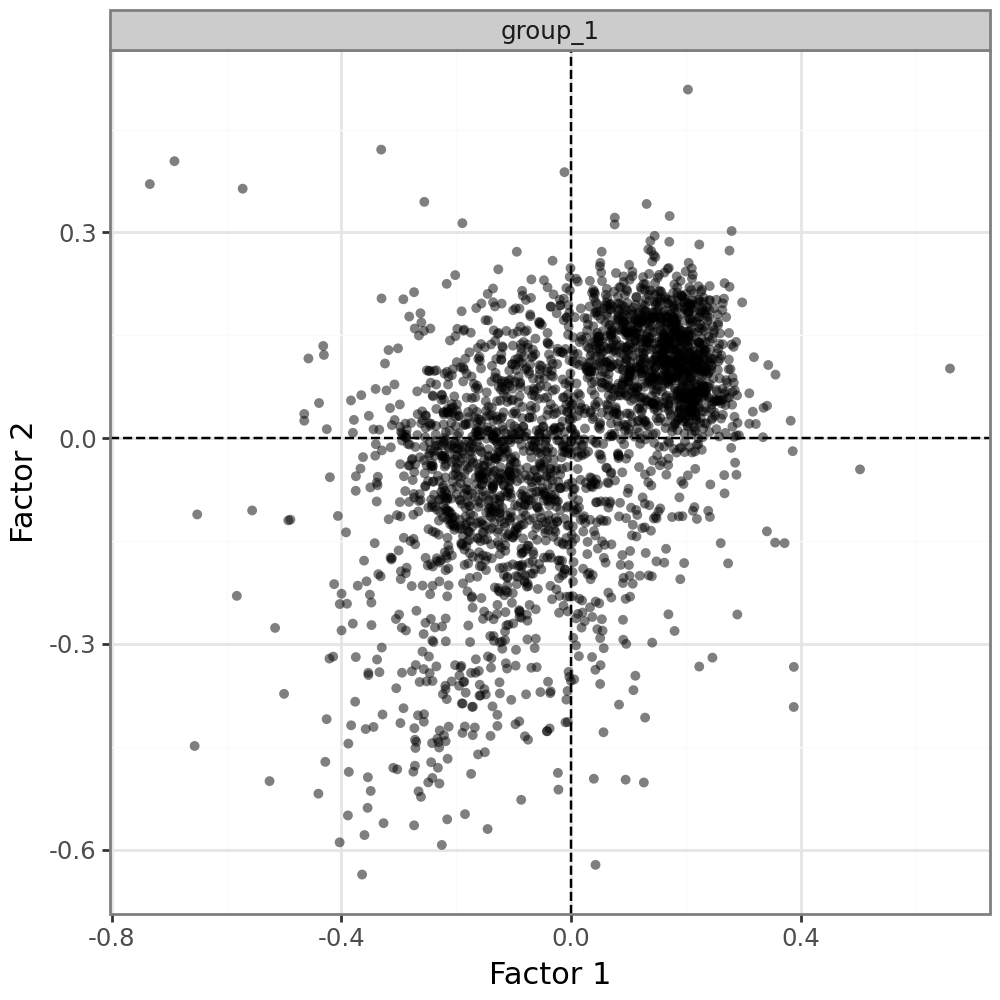

In [15]:
mfl.pl.factors_scatter(model, 1, 2, alpha=0.5)

Of course, MOFA-FLEX does not and cannot provide all imaginable analysis functions.
It thus provides methods to access the factor and weight values, such that they can be used for manual analysis.

In [16]:
weights = model.get_weights()
factors = model.get_factors()

weights["rna"]

,AL627309.1,AL627309.5,AL627309.4,AL669831.2,LINC01409,LINC01128,LINC00115,FAM41C,AL645608.2,SAMD11,...,MT-ND6,MT-CYB,AC145212.1,MAFIP,AC011043.1,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC007325.4
Factor 1,-0.003369,0.229555,0.036156,-0.002039,-0.060745,-0.026323,0.036099,-0.000373,0.008382,0.017810,...,-0.055248,0.287274,-0.003354,0.019620,0.016971,0.022376,0.127316,-0.095337,-0.063165,0.074479
Factor 2,0.040930,0.052586,-0.011065,-0.001327,-0.041336,0.066505,0.030577,-0.083592,-0.002039,0.014398,...,0.304082,-0.306132,-0.015396,0.018979,-0.008697,0.017388,0.052706,0.153000,0.082314,-0.058429
Factor 3,0.003506,0.098337,0.034596,-0.024558,-0.017066,-0.175047,0.004286,0.057944,0.003272,0.011795,...,0.068875,0.051703,-0.025271,-0.063943,-0.033071,0.016096,-0.042113,0.014349,-0.011768,-0.008950
Factor 4,0.025087,0.120917,0.025098,-0.007739,-0.040070,0.097124,-0.011110,0.031564,0.005599,0.002197,...,-0.381125,0.035352,0.011291,-0.021711,-0.041224,0.000940,-0.127549,-0.078901,-0.021781,0.033762
Factor 5,0.028671,0.190195,0.001103,-0.029735,0.146567,-0.119405,0.039485,0.014929,0.007391,-0.000328,...,0.157269,-0.042353,0.021387,-0.067212,0.010125,0.022400,-0.082432,-0.005487,0.055803,0.010475
Factor 6,-0.084535,-0.154048,-0.001823,-0.009108,0.010717,-0.020703,-0.020241,0.025121,-0.005138,0.025157,...,-0.047877,-0.433612,-0.022983,-0.011416,-0.029270,0.025823,0.138140,-0.051577,-0.217958,-0.025325
Factor 7,-0.041024,-0.227711,0.007664,-0.014812,-0.038627,0.006219,-0.004222,0.015292,-0.003111,-0.018779,...,0.178931,0.272208,0.006566,0.003406,0.003212,-0.049351,-0.142464,-0.018735,0.197454,0.056742
Factor 8,0.041606,0.289898,0.029313,-0.028552,0.012537,-0.074284,-0.037165,0.009465,0.009050,-0.052935,...,-0.232013,-0.166025,-0.016606,-0.013059,-0.008256,-0.028945,-0.492879,-0.079297,-0.125508,0.074231
Factor 9,0.058205,0.251303,0.036022,0.023684,-0.005810,-0.170403,-0.026776,-0.087468,0.003024,0.045087,...,-0.512360,-0.521342,-0.027849,0.082516,-0.006422,-0.024221,0.085522,0.056287,-0.087087,0.029497
Factor 10,-0.029879,-0.102851,-0.002710,-0.070254,0.010066,-0.126513,0.013362,-0.052477,-0.006365,0.029289,...,-0.366147,0.224436,0.038440,-0.015131,-0.018851,0.068606,0.162632,0.017538,0.083801,-0.034108


In [17]:
weights["atac"]

,chr1:267561-268455,chr1:629484-630393,chr1:778284-779202,chr1:844149-845034,chr1:857873-858632,chr1:923392-924241,chr1:958865-959762,chr1:1012993-1013910,chr1:1040399-1041292,chr1:1068892-1069685,...,GL000205.2:67744-68642,GL000219.1:39937-40840,GL000219.1:44650-45512,GL000219.1:45733-46550,GL000219.1:90065-90960,GL000219.1:125017-125889,KI270721.1:2089-2980,KI270726.1:27153-28037,KI270726.1:41489-42329,KI270713.1:29578-30400
Factor 1,0.093625,-0.197347,-0.529254,-0.218299,-0.136555,-0.133215,-0.092406,-0.261052,-0.160889,-0.117349,...,0.229476,-0.006712,-0.216790,-0.172089,0.037836,-0.178643,-0.071127,-0.126295,-0.040502,-0.164786
Factor 2,-0.071210,0.224959,-0.380687,-0.128976,-0.021996,0.051678,-0.434483,-0.278360,-0.514377,0.022723,...,0.289003,-0.052269,-0.218866,-0.815085,-0.041106,-0.109560,-0.099433,-0.081152,0.009920,-0.016886
Factor 3,0.018187,0.116989,0.187337,-0.407885,-0.114788,0.000204,0.004758,-0.092927,-0.397291,-0.188143,...,0.440283,-0.132559,0.062732,0.052274,-0.011191,0.085891,0.123530,-0.054808,0.010603,-0.172059
Factor 4,0.041091,-0.175974,-0.120624,0.323556,0.249758,-0.114868,0.043049,0.192886,0.104432,0.005056,...,-0.365985,-0.241053,0.046852,-0.411862,-0.113902,-0.030462,0.058301,0.007679,0.034089,0.059204
Factor 5,0.120425,-0.295849,-0.030803,0.047227,-0.166806,-0.137349,-0.035426,0.395903,-0.076062,-0.210338,...,-0.431284,0.181533,0.170958,0.565543,0.211594,-0.086305,0.040010,-0.017347,-0.102172,-0.043000
Factor 6,-0.144055,0.223146,0.312335,0.163448,0.177453,-0.049665,0.458183,-0.000150,0.033072,0.576281,...,-0.064505,-0.095819,0.042754,-0.071886,0.052831,-0.156517,-0.024892,-0.017815,0.264076,0.038693
Factor 7,-0.017549,0.235117,0.175794,-0.023891,-0.002118,0.374435,0.020983,0.162736,0.169410,0.551788,...,0.207057,0.202270,0.054410,-0.283485,-0.044480,0.061010,0.005537,0.107159,0.144440,-0.008067
Factor 8,0.132234,0.167230,0.197889,0.110263,-0.026068,0.203694,-0.093888,-0.152054,-0.366293,-0.341586,...,-0.062279,-0.407535,0.019664,-0.332685,-0.255404,-0.015079,0.003098,0.100067,-0.084710,0.123323
Factor 9,-0.157556,-0.194359,0.003878,-0.388590,-0.185162,-0.128582,-0.277879,-0.348021,-0.374420,-0.451253,...,-0.313649,0.300444,0.086447,0.287528,0.013511,0.066506,-0.143343,-0.151147,-0.110044,-0.179464
Factor 10,0.047502,0.437500,-0.191484,0.150286,0.178958,-0.064960,0.266366,0.146812,0.271143,0.379279,...,0.209762,-0.084313,-0.104663,0.151292,-0.132510,0.056410,-0.145214,0.057493,-0.070193,-0.007658


In [18]:
factors["group_1"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
AAACAGCCAAATATCC-1,-0.651354,-0.111289,-0.081001,-0.444948,0.295267,0.166918,-0.203074,-0.126044,0.029653,-0.060902,0.153205,0.036405,-0.283844,0.237512,0.117960
AAACAGCCAGGAACTG-1,0.130591,0.202932,0.132278,0.000221,0.061948,-0.189341,-0.238509,0.041560,-0.087694,-0.086881,0.099825,-0.075469,-0.046610,0.248285,-0.036217
AAACAGCCAGGCTTCG-1,0.335585,0.044265,0.093265,0.186891,0.089948,-0.115906,-0.215857,0.208605,0.288055,-0.118198,0.107923,0.117801,-0.061739,-0.025172,0.196676
AAACCAACACCTGCTC-1,0.056109,-0.008513,0.329377,-0.308576,-0.467047,0.067494,0.140154,0.087651,-0.038893,0.105734,0.003682,0.149376,-0.095180,-0.131612,0.037422
AAACCAACAGATTCAT-1,-0.225077,-0.593248,-0.050676,-0.484365,0.309774,0.061197,-0.140485,0.044824,0.057389,0.173536,0.055116,-0.026470,-0.189762,0.029257,0.023662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTGTGCATTGTGTG-1,0.085864,0.112079,-0.347571,0.342599,-0.346152,0.383592,0.563582,-0.112370,0.311802,-0.124510,-0.150193,-0.027703,0.056782,0.429545,0.299680
TTCCCACAGGCGAATA-1,0.167107,0.062056,0.186582,0.062905,0.016751,-0.171516,-0.168844,0.083047,0.074262,-0.070655,0.089945,-0.062206,-0.039492,0.206898,0.025103
TTGCTTAGTCCTTTAA-1,0.198106,-0.020364,0.251698,0.087229,0.117530,0.143039,-0.165827,0.160511,0.088175,-0.058427,-0.092432,0.005562,-0.026642,0.038299,0.217788
TTGTCCGGTGCATTAG-1,0.191514,0.102588,0.100780,0.052819,0.039452,-0.084437,-0.265816,0.164700,0.102887,-0.111328,0.158813,0.044017,-0.051648,0.061480,0.089852
